Min separation at year: 1957.9592552552554 rho = 1.693153220816202
Max separation at year: 1980.4746546546546 rho = 21.712414690918774
r min/max: 8.405911289999999 26.580069248364325
expected peri/apo: 8.405911289999999 26.58008871
max(rho/r): 0.9999986898216502
min(rho/r): 0.1866447652415608
max |Kepler residual|: 8.881784197001252e-16


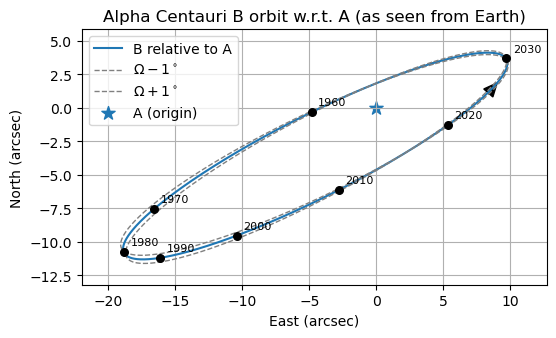

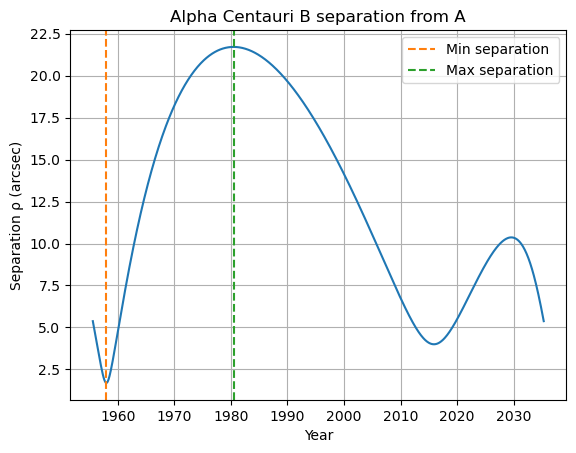

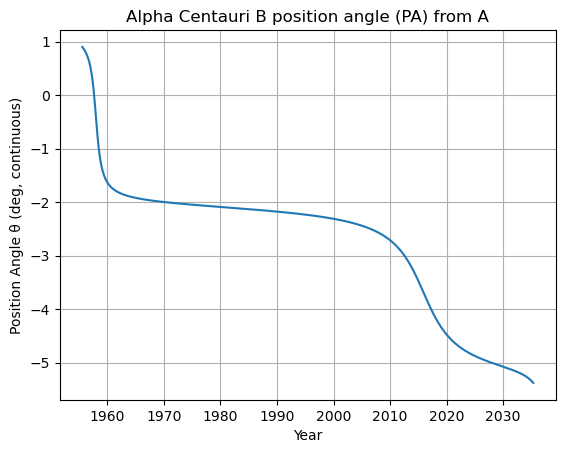

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Alpha Centauri A & B apparent orbit (B about A)
P = 79.7620          # years
a = 17.4930         # arcsec (apparent semi-major axis)
e = 0.51947         # eccentricity
i_deg = 79.243     # inclination (deg)
Omega_deg = 205.073 # longitude of ascending node (deg)
omega_deg = 231.519 # argument of periastron (deg)
T0 = 1955.564       # periastron epoch (year)

i = np.deg2rad(i_deg)
Omega = np.deg2rad(Omega_deg)
omega = np.deg2rad(omega_deg)

def solve_kepler(M, e, tol=1e-5, max_iter=50):
    """Solve E - e sin(E) = M for eccentric anomaly E"""
    M = np.asarray(M)
    E = M + e*np.sin(M)  # good initial guess for moderate e
    for _ in range(max_iter): # Newton's method
        f = E - e*np.sin(E) - M  # note f is 0
        df = 1 - e*np.cos(E)
        dE = -f/df
        E = E + dE
        if np.all(np.abs(dE) < tol):
            break
    return E

def apparent_orbit(t_year):
    """Offsets of B relative to A on sky: x = east, y = north; in arcsec"""
    M = 2*np.pi*(t_year - T0)/P
    M = np.mod(M, 2*np.pi)  # keep it well-behaved numerically
    E = solve_kepler(M, e)

    # true anomaly
    nu = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))
    r = a*(1 - e*np.cos(E))  # arcsec; equation of ellipse

    # projection in sky (visual binary convention)
    x = r*(np.cos(Omega)*np.cos(nu+omega) - np.sin(Omega)*np.sin(nu+omega)*np.cos(i))  # east
    y = r*(np.sin(Omega)*np.cos(nu+omega) + np.cos(Omega)*np.sin(nu+omega)*np.cos(i))  # north
    return x, y, r, M, E

# --- Sensitivity analysis: Omega ± 1 degree ---
dOmega = np.deg2rad(1.0)

def apparent_orbit_with_Omega(t_year, Omega_use):
    M = 2*np.pi*(t_year - T0)/P
    M = np.mod(M, 2*np.pi)
    E = solve_kepler(M, e)

    nu = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2),
                      np.sqrt(1-e)*np.cos(E/2))
    r = a*(1 - e*np.cos(E))

    x = r*(np.cos(Omega_use)*np.cos(nu+omega)
           - np.sin(Omega_use)*np.sin(nu+omega)*np.cos(i))
    y = r*(np.sin(Omega_use)*np.cos(nu+omega)
           + np.cos(Omega_use)*np.sin(nu+omega)*np.cos(i))
    return x, y

# plot one full orbit
t = np.linspace(T0, T0 + P, 1000)
x_e, y_n, r, M, E = apparent_orbit(t)

x_minus, y_minus = apparent_orbit_with_Omega(t, Omega - dOmega)
x_plus,  y_plus  = apparent_orbit_with_Omega(t, Omega + dOmega)

# observables
rho = np.sqrt(x_e**2 + y_n**2)            # arcsec separation
theta_rad = np.arctan2(x_e, y_n)          # radians, (-pi, pi]
theta_unwrapped = np.unwrap(theta_rad)    # unwrap in radians
theta_deg = np.degrees(theta_unwrapped)   # continuous degrees

# Epochs of minimum and maximum apparent separation
t_rho_min = t[np.argmin(rho)]
t_rho_max = t[np.argmax(rho)]

print("Min separation at year:", t_rho_min, "rho =", rho.min())
print("Max separation at year:", t_rho_max, "rho =", rho.max())

# --- Sanity checks ---
r_peri, r_apo = a*(1-e), a*(1+e)
print("r min/max:", r.min(), r.max())
print("expected peri/apo:", r_peri, r_apo)

print("max(rho/r):", np.max(rho / r))
print("min(rho/r):", np.min(rho / r))

kepler_resid = E - e*np.sin(E) - M
print("max |Kepler residual|:", np.max(np.abs(kepler_resid)))

# --- Plots ---
# Orbit
plt.figure(figsize=(6,6))
plt.plot(x_e, y_n, label="B relative to A")

# Time markers every 10 years
years_mark = np.arange(1960, 2031, 10)
idx = [np.argmin(np.abs(t - yr)) for yr in years_mark]

plt.scatter(x_e[idx], y_n[idx], s=30, color="black", zorder=3)

for i, yr in zip(idx, years_mark):
    plt.text(x_e[i] + 0.5, y_n[i] + 0.5, str(yr), fontsize=8)

# Direction of motion arrow
k = 875  # pick a representative index
plt.arrow(
    x_e[k], y_n[k],
    x_e[k+5] - x_e[k],
    y_n[k+5] - y_n[k],
    head_width=0.9,
    head_length=1.0,
    length_includes_head=True,
    color="black")

# Sensitivity envelope: Omega ± 1°
plt.plot(x_minus, y_minus, linestyle="--", color="gray", linewidth=1,
         label=r"$\Omega - 1^\circ$")
plt.plot(x_plus, y_plus, linestyle="--", color="gray", linewidth=1,
         label=r"$\Omega + 1^\circ$")
    
plt.scatter([0],[0], marker='*', s=100, label="A (origin)")
plt.gca().set_aspect('equal', 'box')
plt.xlabel("East (arcsec)")
plt.ylabel("North (arcsec)")
plt.title("Alpha Centauri B orbit w.r.t. A (as seen from Earth)")
plt.margins(0.1)
plt.grid(True)
plt.legend()
plt.savefig("Orbit.png", bbox_inches="tight", pad_inches=0.2, dpi=300)
    
# ρ vs time
plt.figure()
plt.plot(t, rho)
plt.axvline(t_rho_min, linestyle="--", color="C1", label="Min separation")
plt.axvline(t_rho_max, linestyle="--", color="C2", label="Max separation")
plt.xlabel("Year")
plt.ylabel("Separation ρ (arcsec)")
plt.title("Alpha Centauri B separation from A")
plt.legend()
plt.grid(True)
plt.savefig("Separation.png", bbox_inches="tight", pad_inches=0.2, dpi=300)

# θ vs time (unwrapped)
plt.figure()
plt.plot(t, theta_unwrapped)
plt.xlabel("Year")
plt.ylabel("Position Angle θ (deg, continuous)")
plt.title("Alpha Centauri B position angle (PA) from A")
plt.grid(True)
plt.savefig("Angle.png", bbox_inches="tight", pad_inches=0.2, dpi=300)
plt.show()